# DBSCAN EDA — 체공시간 보정 무브먼트 군집 분석

`data/processed/{연도}_movement_reconciliation.csv` 의 **`ivb_ft`(보정 수직 무브먼트)**, **`hb_ft`(보정 수평 무브먼트, 암사이드 +)** 두 변수에 DBSCAN을 적용한다.

## 이 노트북의 흐름

| 단계 | 내용 |
|---|---|
| 1 | 데이터 로드 (`YEARS=None` 이면 읽을 수 있는 모든 연도) |
| 2 | **군집화 전 전체 분포 확인 (라벨 없는 산점도 · 밀도)** |
| 3 | 표본 추출 및 train/test 8:2 무작위 분할 |
| 4 | k-distance 그래프로 `eps` 후보 탐색 |
| 5 | `eps` × `min_samples` 그리드 탐색 |
| 6 | train 데이터로 DBSCAN 학습 |
| 7 | test 데이터에 라벨 할당 (최근접 core sample) |
| 8 | 실루엣 계수 · 데이비스-볼딘 지수 등 평가 |
| 9 | 군집별 색상 scatter plot 등 시각화 |
| 10 | 해석 및 한계 |

## train/test 를 다루는 방식

DBSCAN은 비지도 학습이라 scikit-learn에 `predict()` 가 없다. 이 노트북은 다음과 같이 처리한다.

1. train 데이터로 `fit` → 군집 구조(core sample 집합)를 만든다
2. test 데이터의 각 점에 대해 **가장 가까운 core sample** 을 찾는다
3. 그 거리가 `eps` 이내면 해당 core sample의 군집으로, 아니면 노이즈(`-1`)로 라벨링한다

이는 DBSCAN의 정의(core point의 `eps` 이웃은 같은 군집)를 그대로 확장한 것으로, `sklearn` 문서와 다수 구현에서 쓰는 관행적인 방법이다. train/test 지표를 나란히 보면 **군집 구조가 새로운 데이터에서도 재현되는지** 를 확인할 수 있다.

In [10]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn
print("scikit-learn", sklearn.__version__, "| matplotlib", mpl.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | numpy 2.5.3
scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2


## 0. 파라미터

이 셀만 고치면 된다. `YEARS = None` 이면 `data/processed/` 에서 읽을 수 있는 **모든** `{연도}_movement_reconciliation.csv` 를 사용하고, `YEARS = [2024]` 처럼 지정하면 해당 연도만 사용한다.

In [11]:
# ---------------------------------------------------------------- 데이터 선택
YEARS: list[int] | None = None   # None = 읽을 수 있는 모든 연도 / 예: [2024] 또는 [2021, 2022]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# 군집에 사용할 변수 — 순서가 곧 [x축, y축] 이다. 둘을 바꾸면 모든 산점도가 같이 바뀐다.
FEATURES = ["hb_ft", "ivb_ft"]
EXTRA_COLUMNS = ["game_year", "pitch_type", "p_throws"]  # 해석용으로 같이 읽을 변수

# ------------------------------------------------------------------- 표본/분할
# 전체 190만 행에 DBSCAN + 실루엣을 그대로 돌리면 메모리·시간이 감당되지 않는다.
# 아래 크기로 무작위 추출한 뒤 8:2 로 나눈다. None 이면 전체 사용(권장하지 않음).
SAMPLE_SIZE: int | None = 100_000
TEST_SIZE = 0.2
RANDOM_STATE = 42

# --------------------------------------------------------------- DBSCAN 파라미터
MIN_SAMPLES = 25          # 한 점이 core 가 되기 위한 eps 이웃 최소 개수
EPS: float | None = None  # None 이면 아래 그리드 탐색 결과에서 자동 선택
EPS_GRID = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.75, 1.00]
MIN_SAMPLES_GRID = [10, 25, 50]

# ivb_ft, hb_ft 는 둘 다 inch 단위이고 분산도 비슷해서 표준화하지 않는 편이
# eps 해석(“몇 inch 반경”)이 직관적이다. True 로 바꾸면 StandardScaler 를 적용한다.
SCALE_FEATURES = False

# ------------------------------------------------------------------- 지표 계산
SILHOUETTE_SAMPLE = 20_000  # 실루엣은 O(n^2) 메모리라 이 크기로 부분표본 사용

# 군집 하나가 이 비율 이상을 차지하면 “사실상 한 덩어리”로 보고 경고한다.
DEGENERATE_SHARE = 0.90
# 전체의 이 비율 이상을 담은 군집만 '실질적인 군집'으로 센다 (점 몇십 개짜리는 이상치 덩어리).
MIN_CLUSTER_SHARE = 0.01
# 군집이 이보다 많으면 과분할로 보고 자동 선택 후보에서 제외한다.
MAX_CLUSTERS = 20

In [12]:
# ------------------------------------------------------------ 시각화 공통 설정
# 색맹 안전성 검증을 통과한 3색 팔레트(scatter 는 모든 쌍이 구분되어야 해서 3색까지만 사용).
# 군집이 3개를 넘으면 크기 상위 3개만 색을 주고 나머지는 "기타"로 묶는다.
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue / orange / aqua
OTHER_COLOR = "#6b6a66"   # 기타 군집 (무채색 — 계열색을 흉내 내지 않도록)
NOISE_COLOR = "#c3c2b7"   # 노이즈(-1)
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

# 한글 폰트 — 없으면 축·범례의 한글이 모두 네모(두부)로 깨진다.
import matplotlib.font_manager as fm

KOREAN_FONTS = ["Malgun Gothic", "AppleGothic", "NanumGothic",
                "NanumBarunGothic", "Noto Sans CJK KR", "Noto Sans KR", "Gulim", "Noto Sans CJK JP"]
_available = {f.name for f in fm.fontManager.ttflist}
_picked = next((f for f in KOREAN_FONTS if f in _available), None)
if _picked:
    print(f"한글 폰트: {_picked}")
else:
    print("⚠️  한글 폰트를 찾지 못했습니다. 그래프의 한글이 네모로 표시될 수 있습니다.\n"
          "    Windows 는 보통 'Malgun Gothic' 이 기본 설치되어 있습니다. "
          "없다면 나눔고딕을 설치한 뒤 커널을 재시작하세요.")

sns.set_theme(style="white")
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlepad": 12, "figure.dpi": 110,
    "axes.unicode_minus": False,   # 한글 폰트에서 마이너스 기호가 깨지는 것 방지
})
if _picked:
    mpl.rcParams["font.family"] = _picked


def cluster_color_map(labels: np.ndarray) -> dict[int, str]:
    """군집 라벨 → 색. 크기 상위 3개만 계열색, 나머지는 '기타', -1 은 노이즈."""
    sizes = pd.Series(labels[labels != -1]).value_counts()
    mapping = {-1: NOISE_COLOR}
    for rank, label in enumerate(sizes.index):
        mapping[int(label)] = SERIES_COLORS[rank] if rank < len(SERIES_COLORS) else OTHER_COLOR
    return mapping


def cluster_display_name(label: int, rank: int | None) -> str:
    if label == -1:
        return "노이즈 (-1)"
    if rank is not None and rank >= len(SERIES_COLORS):
        return f"기타 (군집 {label})"
    return f"군집 {label}"

# 축 라벨 — 변수명 하나당 한 번만 정의해두고 모든 그림이 여기서 가져다 쓴다.
AXIS_LABELS = {
    "ivb_ft": "ivb_ft — 보정 수직 무브먼트",
    "hb_ft": "hb_ft — 보정 수평 무브먼트, 암사이드 +",
}


def axis_label(column: str, with_unit: bool = True) -> str:
    base = AXIS_LABELS.get(column, column)
    return f"{base} ({unit})" if with_unit and "unit" in globals() else base


# 표 출력 — pandas 의 .style 은 jinja2 를 요구한다. 설치돼 있지 않아도 죽지 않도록
# 감싸서, 없으면 서식 없는 평범한 표로 대신 보여준다.
METRIC_FORMATS = {
    "noise_ratio": "{:.2%}", "largest_cluster_share": "{:.2%}",
    "silhouette": "{:.4f}", "davies_bouldin": "{:.4f}", "calinski_harabasz": "{:,.0f}",
}


def show_table(frame, formats=None, gradient=None, caption=None):
    """DataFrame 을 서식과 함께 출력한다. jinja2 가 없으면 평범한 표로 대체한다."""
    try:
        styler = frame.style
    except (AttributeError, ImportError):
        if caption:
            print(caption)
        display(frame.round(4) if hasattr(frame, "round") else frame)
        return
    if formats is not None:
        styler = styler.format(formats)
    if gradient:
        keep = [c for c in gradient if c in frame.columns and frame[c].notna().any()]
        if keep:
            styler = styler.background_gradient(subset=keep, cmap="Blues")
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

한글 폰트: Malgun Gothic


## 1. 데이터 로드

`{연도}_movement_reconciliation.csv` 를 찾아 필요한 컬럼만 읽는다. 파일이 연도당 200~330MB라 **필요한 컬럼만 지정해서** 읽는 것이 중요하다.

In [13]:
FILE_PATTERN = re.compile(r"^(?P<year>\d{4})_movement_reconciliation\.csv$")


def find_movement_files(processed_dir: Path, years: list[int] | None = None) -> dict[int, Path]:
    """{연도}_movement_reconciliation.csv 를 찾아 {연도: 경로} 로 반환한다."""
    if not processed_dir.is_dir():
        raise FileNotFoundError(f"디렉토리를 찾을 수 없습니다: {processed_dir}")

    found: dict[int, Path] = {}
    for path in sorted(processed_dir.iterdir()):
        match = FILE_PATTERN.match(path.name)
        if path.is_file() and match:
            found[int(match.group("year"))] = path

    if not found:
        raise FileNotFoundError(
            f"{processed_dir} 에 '{{연도}}_movement_reconciliation.csv' 가 없습니다. "
            "먼저 src/preprocessing/compute_movement_reconciliation.py 를 실행하세요."
        )

    if years is not None:
        wanted = {int(y) for y in years}
        missing = wanted - found.keys()
        if missing:
            raise FileNotFoundError(f"요청한 연도의 파일이 없습니다: {sorted(missing)}")
        found = {y: p for y, p in found.items() if y in wanted}

    return dict(sorted(found.items()))


def load_movement_data(files: dict[int, Path]) -> pd.DataFrame:
    """필요한 컬럼만 읽어 하나의 DataFrame 으로 합친다."""
    usecols = FEATURES + EXTRA_COLUMNS
    frames = []
    for year, path in files.items():
        frame = pd.read_csv(path, usecols=usecols, low_memory=False)
        print(f"  {path.name}: {len(frame):,}행")
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


files = find_movement_files(PROCESSED_DIR, YEARS)
print(f"사용 연도: {sorted(files)}  (YEARS={YEARS})")
data = load_movement_data(files)
print(f"\n합계: {len(data):,}행, {data.shape[1]}컬럼")

사용 연도: [2021, 2022, 2023, 2024, 2025]  (YEARS=None)
  2021_movement_reconciliation.csv: 430,613행
  2022_movement_reconciliation.csv: 355,188행
  2023_movement_reconciliation.csv: 418,446행
  2024_movement_reconciliation.csv: 414,669행
  2025_movement_reconciliation.csv: 281,985행

합계: 1,900,901행, 5컬럼


In [14]:
# 군집 변수에 결측이 있는 행은 제외 (보정이 불가능했던 투구)
before = len(data)
data = data.dropna(subset=FEATURES).reset_index(drop=True)
print(f"결측 제거: {before:,} → {len(data):,}행 (제거 {before - len(data):,})")

display(data[FEATURES].describe().T.round(3))
display(
    data.groupby("pitch_type")[FEATURES]
    .agg(["count", "mean", "std"])
    .round(2)
)

결측 제거: 1,900,901 → 1,900,901행 (제거 0)


,count,mean,std,min,25%,50%,75%,max
hb_ft,1900901.0,8.257,6.526,-20.484,4.129,8.679,13.278,32.480
ivb_ft,1900901.0,12.808,5.468,-14.245,9.058,13.943,17.002,33.091


hb_ft                ivb_ft             
              count   mean   std    count   mean   std
pitch_type                                            
FC           259281  -2.39  3.28   259281   8.18  4.31
FF          1118458   7.58  4.10  1118458  16.03  3.10
SI           523162  14.98  3.34   523162   8.21  5.00

## 2. 군집화 전 — 전체 분포 확인

군집 알고리즘을 돌리기 **전에** 라벨 없는 원래 분포부터 본다. DBSCAN은 밀도가 끊기는 곳에서만 군집을 나누므로, "눈으로 봐서 덩어리가 갈라지는가"가 곧 이 알고리즘이 먹힐지에 대한 1차 판단 근거가 된다.

> 이 절은 `data` (1번에서 읽은 전체 행)를 그대로 쓴다. 표본 추출과 train/test 분할은 다음 절에서 한다.

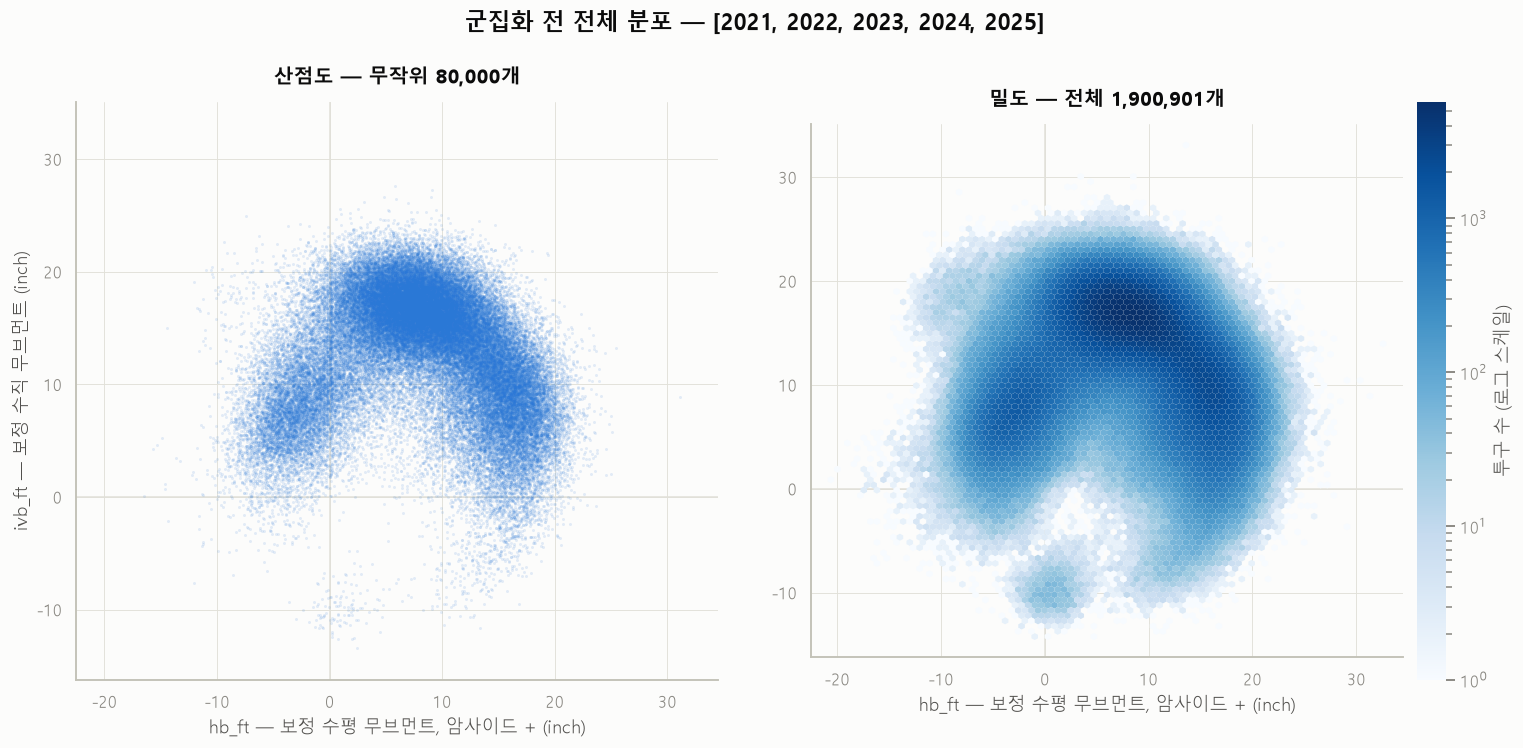

In [15]:
# 점이 수십만~수백만 개라 전부 찍으면 느리고 겹쳐서 아무것도 안 보인다.
# 왼쪽은 부분표본 산점도(개별 점의 산포), 오른쪽은 전체 행의 밀도(hexbin).
OVERVIEW_SAMPLE = 80_000

plot_sample = data.sample(min(OVERVIEW_SAMPLE, len(data)), random_state=RANDOM_STATE)
x_col, y_col = FEATURES          # [x축, y축]
xs, ys = plot_sample[x_col].to_numpy(), plot_sample[y_col].to_numpy()
x_all, y_all = data[x_col].to_numpy(), data[y_col].to_numpy()

pad = 2.0
xlim = (x_all.min() - pad, x_all.max() + pad)
ylim = (y_all.min() - pad, y_all.max() + pad)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.6))

# (왼쪽) 라벨 없는 산점도 — 단일 계열이므로 범례 없음
axes[0].scatter(xs, ys, s=4, c=SERIES_COLORS[0], alpha=0.12, linewidths=0, rasterized=True)
axes[0].set_title(f"산점도 — 무작위 {len(plot_sample):,}개")

# (오른쪽) 전체 행의 밀도 — 단일 색상 ramp, 개수는 로그 스케일
hb = axes[1].hexbin(x_all, y_all, gridsize=90, cmap="Blues", bins="log",
                    mincnt=1, extent=(*xlim, *ylim), linewidths=0)
cbar = fig.colorbar(hb, ax=axes[1], pad=0.02)
cbar.set_label("투구 수 (로그 스케일)", color=INK_2)
cbar.outline.set_visible(False)
axes[1].set_title(f"밀도 — 전체 {len(data):,}개")

for ax in axes:
    ax.set_xlabel(f"{AXIS_LABELS[x_col]} (inch)")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.axvline(0, color=GRID, linewidth=1, zorder=0)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linewidth=0.6)
axes[0].set_ylabel(f"{AXIS_LABELS[y_col]} (inch)")

fig.suptitle(f"군집화 전 전체 분포 — {sorted(files)}",
             fontsize=15, fontweight="bold", color=INK, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

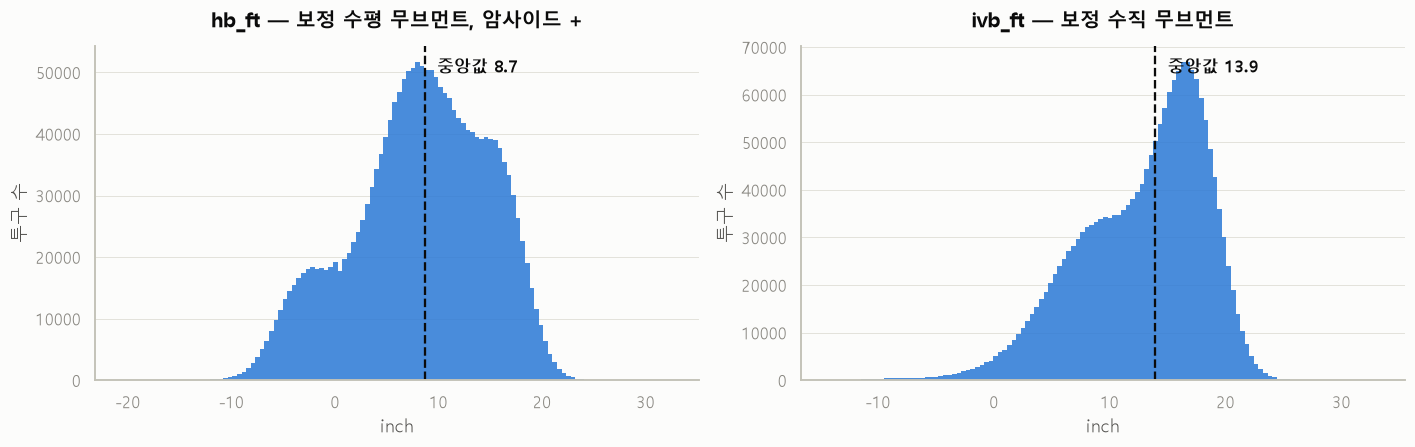

전체 1,900,901개 투구
  hb_ft  : 중앙값   8.68 | 사분위   4.13 ~  13.28 | 범위 -20.48 ~  32.48
  ivb_ft : 중앙값  13.94 | 사분위   9.06 ~  17.00 | 범위 -14.24 ~  33.09
  상관계수: -0.113

[읽는 법] 오른쪽 밀도 그림에서 색이 옅어지는 '골짜기'가 보이면 DBSCAN 이 그 선을 따라
          군집을 나눌 수 있다. 골짜기 없이 한 덩어리로 이어져 있다면 어떤 eps 를 줘도
          깔끔하게 안 나뉜다 — 10번 절의 한계 설명을 참고할 것.


In [16]:
# 각 축의 주변분포 (marginal distribution)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, column in zip(axes, FEATURES):
    label = AXIS_LABELS[column]
    values = data[column].to_numpy()
    ax.hist(values, bins=120, color=SERIES_COLORS[0], alpha=0.85, linewidth=0)
    median = float(np.median(values))
    ax.axvline(median, color=INK, linewidth=1.5, linestyle="--")
    ax.annotate(f"중앙값 {median:.1f}", xy=(median, ax.get_ylim()[1] * 0.92),
                xytext=(8, 0), textcoords="offset points", color=INK, fontweight="bold")
    ax.set_title(label)
    ax.set_xlabel("inch")
    ax.set_ylabel("투구 수")
    ax.grid(axis="y", linewidth=0.6)
fig.tight_layout()
plt.show()

print(f"전체 {len(data):,}개 투구")
for column in FEATURES:
    series = data[column]
    print(f"  {column:<7}: 중앙값 {series.median():6.2f} | 사분위 "
          f"{series.quantile(.25):6.2f} ~ {series.quantile(.75):6.2f} | "
          f"범위 {series.min():6.2f} ~ {series.max():6.2f}")
print(f"  상관계수: {data[FEATURES[0]].corr(data[FEATURES[1]]):.3f}")
print("\n[읽는 법] 오른쪽 밀도 그림에서 색이 옅어지는 '골짜기'가 보이면 DBSCAN 이 그 선을 따라")
print("          군집을 나눌 수 있다. 골짜기 없이 한 덩어리로 이어져 있다면 어떤 eps 를 줘도")
print("          깔끔하게 안 나뉜다 — 10번 절의 한계 설명을 참고할 것.")

## 3. 표본 추출과 train/test 분할

DBSCAN은 이웃 탐색이 필요해 점 개수에 민감하고, 실루엣 계수는 거리 행렬 때문에 메모리가 $O(n^2)$ 다. 그래서 `SAMPLE_SIZE` 만큼 무작위 추출한 뒤 **8:2 무작위 분할** 한다.

> ⚠️ **중요**: DBSCAN의 `eps` 는 *밀도* 에 대한 값이라 표본 크기가 바뀌면 최적값도 바뀐다. `SAMPLE_SIZE` 를 바꿨다면 3~4단계의 `eps` 탐색을 **반드시 다시** 돌려야 한다.

In [ ]:
if SAMPLE_SIZE is not None and len(data) > SAMPLE_SIZE:
    sample = data.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"무작위 추출: {len(data):,} → {len(sample):,}행")
else:
    sample = data.reset_index(drop=True)
    print(f"전체 사용: {len(sample):,}행")

X_raw = sample[FEATURES].to_numpy(dtype=float)

if SCALE_FEATURES:
    scaler = StandardScaler().fit(X_raw)
    X_all = scaler.transform(X_raw)
    unit = "표준화 단위"
else:
    scaler = None
    X_all = X_raw
    unit = "inch"
print(f"특징 공간 단위: {unit}  (SCALE_FEATURES={SCALE_FEATURES})")

idx_train, idx_test = train_test_split(
    np.arange(len(sample)), test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
X_train, X_test = X_all[idx_train], X_all[idx_test]
meta_train = sample.iloc[idx_train].reset_index(drop=True)
meta_test = sample.iloc[idx_test].reset_index(drop=True)

print(f"train {len(X_train):,}행 / test {len(X_test):,}행 "
      f"({1 - TEST_SIZE:.0%} : {TEST_SIZE:.0%} 무작위 분할)")

## 4. `eps` 후보 찾기 — k-distance 그래프

각 점에서 **k번째 가까운 이웃까지의 거리**를 정렬해 그리면, 곡선이 급격히 치솟는 지점(elbow)이 "밀집 영역과 희박 영역의 경계"에 해당한다. DBSCAN의 `eps` 는 보통 그 근처에서 고른다. 여기서는 `k = min_samples - 1` 을 쓴다.

In [ ]:
def k_distances(X: np.ndarray, k: int) -> np.ndarray:
    """각 점의 k번째 최근접 이웃 거리를 정렬해 반환한다."""
    nn = NearestNeighbors(n_neighbors=k + 1, n_jobs=-1).fit(X)
    distances, _ = nn.kneighbors(X)
    return np.sort(distances[:, -1])


def knee_point(sorted_distances: np.ndarray) -> tuple[int, float]:
    """정렬된 곡선의 양 끝점을 잇는 직선에서 가장 멀리 떨어진 지점(elbow)을 찾는다."""
    n = len(sorted_distances)
    x = np.arange(n, dtype=float)
    y = sorted_distances
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    # 점-직선 거리 (정규화 불필요: argmax 만 쓰므로 분모 생략 가능하지만 명시적으로 둔다)
    denom = np.hypot(x1 - x0, y1 - y0)
    distance = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0) / denom
    i = int(np.argmax(distance))
    return i, float(y[i])


k = max(MIN_SAMPLES - 1, 1)
kdist = k_distances(X_train, k)
knee_i, knee_eps = knee_point(kdist)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(np.arange(len(kdist)), kdist, color="#2a78d6", linewidth=2)
ax.axhline(knee_eps, color=MUTED, linewidth=1.2, linestyle="--")
ax.annotate(
    f"elbow ≈ {knee_eps:.3f} {unit}",
    xy=(knee_i, knee_eps), xytext=(12, 26), textcoords="offset points",
    color=INK, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=MUTED, linewidth=1.2),
)
ax.set_title(f"k-distance 그래프 (k = {k})")
ax.set_xlabel("정렬된 점 순서")
ax.set_ylabel(f"{k}번째 최근접 이웃 거리 ({unit})")
ax.set_ylim(0, float(np.quantile(kdist, 0.999)))
ax.grid(axis="y")
plt.tight_layout()
plt.show()

print(f"k-distance 분위수 ({unit}):")
for q in [0.50, 0.80, 0.90, 0.95, 0.98, 0.99]:
    print(f"  {q:.0%}: {np.quantile(kdist, q):.4f}")
print(f"\nelbow 추정 eps ≈ {knee_eps:.4f}")

## 5. `eps` × `min_samples` 그리드 탐색

elbow는 출발점일 뿐이므로, 실제 지표로 격자 탐색을 한다. 각 조합마다 다음을 기록한다.

- **군집 개수** / **노이즈 비율**
- **실루엣 계수** (높을수록 좋음, −1 ~ 1)
- **데이비스-볼딘 지수** (낮을수록 좋음, 0 ~ ∞)
- **최대 군집 점유율** — 한 군집이 전체를 다 먹으면 지표가 좋아 보여도 군집화가 된 게 아니다

In [ ]:
def cluster_metrics(X: np.ndarray, labels: np.ndarray,
                    sample_size: int = SILHOUETTE_SAMPLE,
                    random_state: int = RANDOM_STATE) -> dict:
    """노이즈를 제외하고 실루엣·DB·CH 지수를 계산한다."""
    mask = labels != -1
    unique = np.unique(labels[mask])
    out = {
        "n_clusters": int(len(unique)),
        "noise_ratio": float((~mask).mean()),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "largest_cluster_share": np.nan,
        "n_major_clusters": 0,
    }
    if mask.sum() > 0:
        counts = pd.Series(labels[mask]).value_counts()
        out["largest_cluster_share"] = float(counts.iloc[0] / len(labels))
        # 전체의 MIN_CLUSTER_SHARE 이상을 담은 군집만 '실질적인 군집'으로 센다.
        # 점 수십 개짜리 군집은 이상치 덩어리이지 군집이 아니다.
        out["n_major_clusters"] = int((counts / len(labels) >= MIN_CLUSTER_SHARE).sum())

    # 지표는 군집이 2개 이상일 때만 정의된다
    if len(unique) < 2 or mask.sum() < 10:
        return out

    Xc, lc = X[mask], labels[mask]
    rng = np.random.default_rng(random_state)
    if len(Xc) > sample_size:
        pick = rng.choice(len(Xc), size=sample_size, replace=False)
        # 부분표본에 군집이 하나만 남으면 실루엣이 정의되지 않는다
        if len(np.unique(lc[pick])) >= 2:
            out["silhouette"] = float(silhouette_score(Xc[pick], lc[pick]))
    else:
        out["silhouette"] = float(silhouette_score(Xc, lc))

    out["davies_bouldin"] = float(davies_bouldin_score(Xc, lc))
    out["calinski_harabasz"] = float(calinski_harabasz_score(Xc, lc))
    return out


rows = []
for min_samples in MIN_SAMPLES_GRID:
    for eps in EPS_GRID:
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_train)
        rows.append({"eps": eps, "min_samples": min_samples, **cluster_metrics(X_train, labels)})

grid = pd.DataFrame(rows)
show_table(grid, METRIC_FORMATS, gradient=["silhouette"])

In [ ]:
# 지표 3개를 한 축에 겹쳐 그리면 척도가 달라 거짓말이 된다 → 세로로 나눈 small multiples
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
panels = [
    ("n_clusters", "군집 개수", None),
    ("silhouette", "실루엣 계수 (↑)", None),
    ("davies_bouldin", "데이비스-볼딘 지수 (↓)", None),
]
line_colors = dict(zip(MIN_SAMPLES_GRID, SERIES_COLORS))

for ax, (column, title, _) in zip(axes, panels):
    for min_samples in MIN_SAMPLES_GRID:
        sub = grid[grid.min_samples == min_samples]
        ax.plot(sub.eps, sub[column], marker="o", markersize=6, linewidth=2,
                color=line_colors[min_samples], label=f"min_samples = {min_samples}")
    ax.set_ylabel(title)
    ax.grid(axis="y")
    if column == "n_clusters":
        ax.set_yscale("log")

axes[0].set_title("eps 그리드 탐색 — 지표별 추이")
axes[0].legend(frameon=False, labelcolor=INK_2)
axes[-1].set_xlabel(f"eps ({unit})")
plt.tight_layout()
plt.show()

In [ ]:
# 실용적인 조합 고르기:
#  - 군집이 2개 이상
#  - 노이즈 50% 미만
#  - 한 군집이 DEGENERATE_SHARE 이상을 독식하지 않을 것  ← 퇴화 해 배제
usable = grid[
    (grid.n_major_clusters >= 2)              # 1% 이상짜리 군집이 2개 이상
    & (grid.n_clusters <= MAX_CLUSTERS)       # 과분할 배제
    & (grid.noise_ratio < 0.50)
    & (grid.largest_cluster_share < DEGENERATE_SHARE)
].sort_values("silhouette", ascending=False)

print(f"퇴화하지 않은 조합: {len(usable)} / {len(grid)}개  (조건: 1% 이상 군집 2개+, "
      f"군집 {MAX_CLUSTERS}개 이하, 노이즈 <50%, 최대군집 <{DEGENERATE_SHARE:.0%})")

if EPS is not None:
    best_eps, best_min_samples = EPS, MIN_SAMPLES
    source = "사용자 지정(EPS 파라미터)"
elif len(usable) > 0:
    best_eps = float(usable.iloc[0].eps)
    best_min_samples = int(usable.iloc[0].min_samples)
    source = "그리드 탐색 최고 실루엣"
else:
    # 모든 조합이 퇴화 → 실루엣이 가장 높은 조합을 쓰되 아래에서 경고한다
    fallback = grid[grid.n_clusters >= 2].sort_values("silhouette", ascending=False)
    if len(fallback) == 0:
        best_eps, best_min_samples = knee_eps, MIN_SAMPLES
        source = "k-distance elbow (그리드 전부 군집 1개)"
    else:
        best_eps = float(fallback.iloc[0].eps)
        best_min_samples = int(fallback.iloc[0].min_samples)
        source = "⚠️ 전 조합 퇴화 — 차선책"

print(f"선택: eps = {best_eps}, min_samples = {best_min_samples}  ({source})")
if len(usable) > 0 and usable.iloc[0].silhouette <= 0:
    print("⚠️  퇴화하지 않은 조합 중 실루엣이 양수인 것이 없습니다 "
          "— 이 평면에 뚜렷한 밀도 경계가 없다는 신호입니다.")
if len(usable) > 0:
    show_table(usable.head(5), METRIC_FORMATS, caption="상위 후보 조합")

## 6. DBSCAN 학습 (train)

In [ ]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
train_labels = dbscan.fit_predict(X_train)

core_idx = dbscan.core_sample_indices_
print(f"DBSCAN(eps={best_eps}, min_samples={best_min_samples})")
print(f"  core sample: {len(core_idx):,}개 / {len(X_train):,}")
print(f"  군집 개수  : {len(set(train_labels)) - (1 if -1 in train_labels else 0)}")
print(f"  노이즈     : {(train_labels == -1).sum():,}개 ({(train_labels == -1).mean():.2%})")

train_sizes = pd.Series(train_labels).value_counts().sort_index()
display(train_sizes.rename("점 개수").to_frame().assign(
    비율=lambda d: (d["점 개수"] / len(train_labels)).map("{:.2%}".format)
))

## 7. test 데이터에 라벨 할당

각 test 점에서 가장 가까운 **core sample** 을 찾아, 거리가 `eps` 이내면 그 군집으로, 아니면 노이즈(`-1`)로 라벨링한다.

In [ ]:
def assign_by_nearest_core(model: DBSCAN, X_train: np.ndarray,
                           train_labels: np.ndarray, X_new: np.ndarray) -> np.ndarray:
    """학습된 DBSCAN의 core sample 을 기준으로 새 데이터에 군집 라벨을 붙인다."""
    core_indices = model.core_sample_indices_
    if len(core_indices) == 0:
        return np.full(len(X_new), -1, dtype=int)

    core_points = X_train[core_indices]
    core_labels = train_labels[core_indices]

    nn = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(core_points)
    distances, indices = nn.kneighbors(X_new)
    distances, indices = distances.ravel(), indices.ravel()

    labels = np.where(distances <= model.eps, core_labels[indices], -1)
    return labels.astype(int)


test_labels = assign_by_nearest_core(dbscan, X_train, train_labels, X_test)

print(f"test {len(test_labels):,}개 라벨 할당 완료")
print(f"  군집 개수: {len(set(test_labels)) - (1 if -1 in test_labels else 0)}")
print(f"  노이즈   : {(test_labels == -1).sum():,}개 ({(test_labels == -1).mean():.2%})")

comparison = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts(normalize=True).sort_index(),
    "test": pd.Series(test_labels).value_counts(normalize=True).sort_index(),
}).fillna(0.0)
show_table(comparison, "{:.2%}", caption="군집별 점유율 — train vs test")

## 8. 평가 지표

| 지표 | 범위 | 방향 | 의미 |
|---|---|---|---|
| **실루엣 계수** | −1 ~ 1 | ↑ | 자기 군집에 얼마나 잘 붙어 있고 다른 군집과 얼마나 떨어져 있는지 |
| **데이비스-볼딘 지수** | 0 ~ ∞ | ↓ | (군집 내 산포 + 군집 간 거리) 비율의 평균 |
| **칼린스키-하라바츠 지수** | 0 ~ ∞ | ↑ | 군집 간 분산 / 군집 내 분산 |

세 지표 모두 **노이즈(−1)를 제외**하고 계산한다. 노이즈는 군집이 아니라 "어디에도 속하지 않음"이므로 하나의 군집처럼 취급하면 지표가 왜곡된다.

In [ ]:
scores = pd.DataFrame([
    {"split": "train", **cluster_metrics(X_train, train_labels)},
    {"split": "test",  **cluster_metrics(X_test, test_labels)},
]).set_index("split")

show_table(scores, METRIC_FORMATS, caption="DBSCAN 평가 지표")

print("\n" + "=" * 64)
for split in ["train", "test"]:
    r = scores.loc[split]
    print(f"[{split}] 군집 {int(r.n_clusters)}개 | 노이즈 {r.noise_ratio:.2%} | "
          f"실루엣 {r.silhouette:.4f} | 데이비스-볼딘 {r.davies_bouldin:.4f} | "
          f"칼린스키-하라바츠 {r.calinski_harabasz:,.0f}")
print("=" * 64)

## 9. 시각화

In [ ]:
def plot_clusters(ax, X, labels, title, color_map, ranks):
    """군집별 색상 scatter.

    산점도는 모든 색 쌍이 서로 구분되어야 해서 계열색을 3개까지만 쓴다.
    크기 상위 3개 군집만 개별 색 + 중심 직접 라벨을 주고, 나머지는 '기타'로 한데 묶는다.
    """
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=4, c=NOISE_COLOR,
                   alpha=0.5, linewidths=0, label=f"노이즈 (-1) · n={noise.sum():,}", zorder=1)

    ordered = sorted(set(labels) - {-1}, key=lambda l: -np.sum(labels == l))
    top, rest = ordered[:len(SERIES_COLORS)], ordered[len(SERIES_COLORS):]

    if rest:
        mask = np.isin(labels, rest)
        ax.scatter(X[mask, 0], X[mask, 1], s=5, c=OTHER_COLOR, alpha=0.6, linewidths=0,
                   label=f"기타 군집 {len(rest)}개 · n={mask.sum():,}", zorder=2)

    for label in top:
        mask = labels == label
        ax.scatter(X[mask, 0], X[mask, 1], s=5, c=color_map[label], alpha=0.55, linewidths=0,
                   label=f"군집 {label} · n={mask.sum():,}", zorder=3)
        # 직접 라벨 — 색상만으로 식별하지 않도록 (대비가 낮은 색에 대한 보완)
        cx, cy = X[mask, 0].mean(), X[mask, 1].mean()
        ax.annotate(str(label), (cx, cy), color=INK, fontweight="bold", fontsize=12,
                    ha="center", va="center", zorder=4,
                    bbox=dict(boxstyle="circle,pad=0.25", fc="#fcfcfb", ec=color_map[label], lw=1.5))

    ax.set_title(title)
    ax.set_xlabel(axis_label(FEATURES[0]))
    ax.set_ylabel(axis_label(FEATURES[1]))
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.axvline(0, color=GRID, linewidth=1, zorder=0)
    ax.set_aspect("equal", adjustable="box")  # 두 축 단위가 같으므로 등비율
    ax.grid(True, linewidth=0.6)


color_map = cluster_color_map(train_labels)
ranks = {int(l): r for r, l in enumerate(pd.Series(train_labels[train_labels != -1]).value_counts().index)}

fig, axes = plt.subplots(1, 2, figsize=(14.5, 7.2), sharex=True, sharey=True)
plot_clusters(axes[0], X_train, train_labels, f"train — {len(X_train):,}개", color_map, ranks)
plot_clusters(axes[1], X_test, test_labels, f"test — {len(X_test):,}개", color_map, ranks)

# 두 패널의 축 범위를 맞춰 눈으로 직접 비교할 수 있게 한다
pad = 1.5
axes[0].set_xlim(X_all[:, 0].min() - pad, X_all[:, 0].max() + pad)
axes[0].set_ylim(X_all[:, 1].min() - pad, X_all[:, 1].max() + pad)
axes[1].set_ylabel("")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper center", ncol=min(3, len(handles)),
           frameon=False, labelcolor=INK_2, markerscale=3, bbox_to_anchor=(0.5, 0.075))
fig.suptitle(f"DBSCAN 군집 (eps={best_eps}, min_samples={best_min_samples})",
             fontsize=15, fontweight="bold", color=INK, y=0.99)
fig.tight_layout(rect=(0, 0.10, 1, 0.97))
plt.show()

In [ ]:
# 군집 크기 — 가로 막대
TOP_N_BARS = 12
order = train_sizes.sort_values(ascending=False).head(TOP_N_BARS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8.5, 0.5 * max(len(order), 3) + 1.8))
bar_colors = [color_map.get(int(i), OTHER_COLOR) for i in order.index]
names = [cluster_display_name(int(i), ranks.get(int(i))) for i in order.index]

bars = ax.barh(names, order.values, color=bar_colors, height=0.68)
for bar, value in zip(bars, order.values):
    ax.annotate(f"{value:,} ({value / len(train_labels):.1%})",
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_2, fontsize=10)

ax.set_title(f"군집 크기 (train) — 상위 {min(TOP_N_BARS, len(train_sizes))}개")
ax.set_xlabel("점 개수")
ax.set_xlim(0, order.max() * 1.18)
ax.grid(axis="x", linewidth=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# 군집이 구종(pitch_type)을 복원하는가? — 행 기준 비율 heatmap
# 군집이 많으면 크기 상위 것만 본다 (+ 노이즈)
keep = list(train_sizes.drop(index=-1, errors="ignore").sort_values(ascending=False).head(10).index)
if -1 in train_labels:
    keep = [-1] + keep
mask_keep = np.isin(train_labels, keep)

# 주의: pd.crosstab 은 인덱스를 기준으로 정렬하므로, 마스크로 거른 두 계열을
# 그대로 넘기면 한쪽만 원래 인덱스를 유지해 서로 어긋난다. numpy 배열로 넘긴다.
label_series = pd.Series(train_labels[mask_keep], name="군집")
pitch_series = pd.Series(meta_train["pitch_type"].to_numpy()[mask_keep], name="구종")

crosstab = pd.crosstab(label_series, pitch_series, normalize="index")
counts = pd.crosstab(label_series, pitch_series)

fig, ax = plt.subplots(figsize=(6.2, 0.52 * len(crosstab) + 2.2))
sns.heatmap(crosstab, annot=counts, fmt=",d", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="#fcfcfb", cbar_kws={"label": "행 기준 비율"}, ax=ax)
ax.set_title("군집 × 구종 구성 (숫자는 투구 수, 색은 행 기준 비율)")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

show_table(crosstab, "{:.1%}", caption="군집별 구종 구성비 (train)")

In [ ]:
# 참고: 실제 구종으로 색을 입힌 같은 산점도 — DBSCAN 결과와 비교용
fig, ax = plt.subplots(figsize=(7.4, 6.4))
pitch_colors = dict(zip(["FF", "SI", "FC"], SERIES_COLORS))
for pitch_type, color in pitch_colors.items():
    mask = (meta_train["pitch_type"] == pitch_type).to_numpy()
    if not mask.any():
        continue
    ax.scatter(X_train[mask, 0], X_train[mask, 1], s=5, c=color, alpha=0.45,
               linewidths=0, label=f"{pitch_type} · n={mask.sum():,}")
    cx, cy = X_train[mask, 0].mean(), X_train[mask, 1].mean()
    ax.annotate(pitch_type, (cx, cy), color=INK, fontweight="bold", fontsize=12,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="#fcfcfb", ec=color, lw=1.5))

ax.set_title("참고 — 실제 구종 레이블로 칠한 같은 산점도")
ax.set_xlabel(f"{FEATURES[0]} ({unit})")
ax.set_ylabel(f"{FEATURES[1]} ({unit})")
ax.axhline(0, color=GRID, linewidth=1)
ax.axvline(0, color=GRID, linewidth=1)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linewidth=0.6)
ax.legend(frameon=False, labelcolor=INK_2, markerscale=3)
plt.tight_layout()
plt.show()

## 10. 진단과 해석

In [ ]:
print("=" * 70)
print(f"데이터        : {sorted(files)}  ({len(data):,}행 중 {len(sample):,}행 표본)")
print(f"특징          : {FEATURES}  (단위: {unit})")
print(f"파라미터      : eps={best_eps}, min_samples={best_min_samples}  [{source}]")
print("-" * 70)
for split in ["train", "test"]:
    r = scores.loc[split]
    print(f"{split:<6} 군집 {int(r.n_clusters)}개 (1% 이상 {int(r.n_major_clusters)}개) | "
          f"노이즈 {r.noise_ratio:6.2%} | 최대군집 점유 {r.largest_cluster_share:6.2%} | "
          f"실루엣 {r.silhouette:7.4f} | DB {r.davies_bouldin:6.4f}")
print("=" * 70)

share = scores.loc["train", "largest_cluster_share"]
n_clusters = int(scores.loc["train", "n_clusters"])
n_major = int(scores.loc["train", "n_major_clusters"])

print("\n[진단]")
sil = scores.loc["train", "silhouette"]
if np.isfinite(sil) and sil <= 0:
    print(f"  ⚠️  실루엣 계수가 {sil:.4f} (0 이하) 입니다. 평균적으로 각 점이 자기 군집보다")
    print("      이웃 군집에 더 가깝다는 뜻으로, 사실상 '나뉠 만한 경계가 없다'는 신호입니다.")
    print("      아래 '한계' 절을 참고하세요.")
if n_major <= 1:
    print(f"  ⚠️  실질적으로 군집이 {n_major}개입니다. 전체 {n_clusters}개 중 "
          f"{MIN_CLUSTER_SHARE:.0%} 이상을 담은 군집은 {n_major}개뿐이고,")
    print(f"      나머지는 점 몇십 개짜리 이상치 덩어리입니다. 가장 큰 군집이 {share:.1%} 를 차지합니다.")
elif share >= DEGENERATE_SHARE:
    print(f"  ⚠️  퇴화 해: 가장 큰 군집이 전체의 {share:.1%} 를 차지합니다.")
    print("      나머지 군집은 사실상 이상치 덩어리이고, 이때 실루엣 점수가 높게 나오는 것은")
    print("      '군집이 잘 나뉘어서'가 아니라 '거대한 덩어리 하나 + 멀리 떨어진 점 몇 개' 구조")
    print("      때문입니다. 지표만 보고 군집화가 성공했다고 판단하면 안 됩니다.")
elif n_clusters > 20:
    print(f"  ⚠️  과분할: 군집이 {n_clusters}개입니다. eps 가 너무 작아 밀집 영역이 잘게 쪼개졌습니다.")
elif np.isfinite(sil) and sil > 0:
    print(f"  ✅ 실질 군집 {n_major}개, 최대 점유율 {share:.1%}, 실루엣 {sil:.4f} — 쓸 만한 해입니다.")
else:
    print(f"  ℹ️  실질 군집 {n_major}개, 최대 점유율 {share:.1%} — 군집은 잡혔지만 분리도가 약합니다.")

drift = abs(scores.loc["train", "silhouette"] - scores.loc["test", "silhouette"])
if np.isfinite(drift):
    verdict = "재현됨" if drift < 0.05 else "차이 있음 — 과적합 또는 표본 편차 의심"
    print(f"  train/test 실루엣 차이 {drift:.4f} → {verdict}")

### 이 데이터에서 DBSCAN이 갖는 한계

`ivb_ft` × `hb_ft` 평면 위의 패스트볼은 **밀도 골짜기가 없는 하나의 연속적인 구름**에 가깝다. 구종별 중심은 분명히 떨어져 있지만 —

| 구종 | ivb_ft 평균 | hb_ft 평균 |
|---|---:|---:|
| FF (포심) | 약 16 | 약 +8 |
| SI (싱커) | 약 8 | 약 +15 |
| FC (커터) | 약 8 | 약 −2 |

— 각 구종의 표준편차가 3~5 inch라 세 구름이 **서로 맞닿아 있다**. DBSCAN은 밀도가 끊기는 지점에서만 군집을 나누므로, 이 구조에서는 어떤 `eps` 를 써도 다음 둘 중 하나가 된다.

- `eps` 가 작으면 → 밀집 영역이 수십~수백 개로 잘게 쪼개지고 실루엣이 **음수**가 된다
- `eps` 가 크면 → 전부 하나의 거대 군집 + 가장자리 이상치 몇 개 (퇴화 해)

위 9번 절의 "실제 구종으로 칠한 산점도"와 DBSCAN 결과를 나란히 보면 이 점이 바로 드러난다. **이건 코드 버그가 아니라 데이터 구조와 알고리즘 특성의 문제이며, 그 자체로 유효한 EDA 결론이다.**

다만 완전한 실패는 아니다. 군집 × 구종 교차표를 보면 DBSCAN이 **커터(FC) 영역은 부분적으로 떼어낸다**. 커터는 `hb_ft` 가 음수 쪽(글러브사이드)에 있어 나머지 둘과 밀도가 한 번 끊기기 때문이다. 반면 **포심(FF)과 싱커(SI)는 하나의 거대 군집으로 뭉친다** — 둘의 경계에는 밀도 골짜기가 없다. 이 "FC는 갈라지고 FF/SI는 붙는다"는 관찰 자체가 이 평면의 구조를 말해주는 결과다.

### 다음에 시도해볼 만한 방향

1. **투수-시즌 단위로 집계 후 군집화** — 투구 한 개가 아니라 투수별 평균 `(ivb_ft, hb_ft)` 를 점으로 쓰면 연도당 수천 점으로 줄고, "라이징 패스트볼형 / 싱커볼러형 / 커터형" 같은 **유형 분류**에 훨씬 적합하다. 개인적으로 이 방향이 가장 유망해 보인다.
2. **GaussianMixture (GMM)** — 서로 겹치는 타원형 군집을 가정하므로 이 데이터 모양에 더 맞는다. 군집 수를 BIC로 고르고 DBSCAN 결과와 비교해볼 수 있다.
3. **HDBSCAN** — 밀도가 다른 군집을 동시에 잡아낸다. `eps` 를 직접 고를 필요가 없고, 이 데이터처럼 밀도가 완만하게 변하는 경우 DBSCAN보다 안정적이다.
4. **변수 추가** — `release_speed`, `spin_axis`, `arm_angle` 등을 넣어 차원을 늘리면 구종 간 분리가 뚜렷해질 수 있다. 단, 차원이 늘면 거리 기반 밀도가 희석되는 점(차원의 저주)은 함께 고려해야 한다.